# Part 3 — Real Object Localization with Generalized Hough Transform

This notebook implements **Part 3 only**: detecting a flower object using the **Generalized Hough Transform (GHT)**.

The implementation avoids built-in edge detectors, Sobel functions, Hough functions, template matching, and feature matching. It uses only basic image loading, NumPy operations, and plotting utilities.

Required output progression:

**Original Test Image → Grayscale Test Image → Edge Map → Hough Accumulator Heatmap → Final Detected Location**

## 1. Imports and paths

Update the two image paths below if your actual dataset filenames are different. The homework mentions `test_flower_original.jpg`; the template image name may vary.

In [32]:
import os
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view


base_path = "images/object_localization"
TEMPLATE_PATH = os.path.join(base_path, "template_flower_gray.png")
TEST_PATH = os.path.join(base_path, "test_flower_original.jpg")
OUTPUT_DIR = Path("outputs/object_localization")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: outputs\object_localization


## 2. Utility functions

These functions handle reading images, grayscale conversion, and saving visual outputs.

In [33]:
def read_image(path):
    #Read image using cv2.imread and convert BGR to RGB manually
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img_bgr[:, :, ::-1]


def rgb_to_gray(img_rgb):
    #Manual RGB to grayscale conversion. Output is float32 in [0, 1]
    img = img_rgb.astype(np.float32) / 255.0
    gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    return gray.astype(np.float32)


def show_image(img, title=None, cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def save_image(path, img, cmap=None, title=None, colorbar=False):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap=cmap)
    if title:
        plt.title(title)
    if colorbar:
        plt.colorbar()
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", pad_inches=0)
    plt.close()

## 3. From-scratch filtering and edge detection

The edge detector uses:

1. Gaussian blur implemented from scratch
2. Manual Sobel kernels
3. Gradient magnitude and direction
4. Thresholding to create a binary edge map

No `cv2.Sobel`, `cv2.Canny`, or `scipy.signal.convolve2d` is used.

In [34]:
def gaussian_kernel(size=5, sigma=1.0):
    #Create a normalized 2D Gaussian kernel
    if size % 2 == 0:
        raise ValueError("Gaussian kernel size must be odd.")

    radius = size // 2
    y, x = np.mgrid[-radius:radius + 1, -radius:radius + 1]
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel.astype(np.float32)


def convolve2d_numpy(image, kernel):
    #Vectorized 2D convolution using NumPy sliding windows
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2

    padded = np.pad(image, ((ph, ph), (pw, pw)), mode="reflect")
    windows = sliding_window_view(padded, (kh, kw))
    flipped_kernel = np.flipud(np.fliplr(kernel))

    output = np.einsum("ij,xyij->xy", flipped_kernel, windows)
    return output.astype(np.float32)


def edge_detection_scratch(gray, gaussian_size=5, sigma=1.0, threshold_ratio=0.22):
    #Return binary edge map, gradient magnitude, and gradient direction
    blur_kernel = gaussian_kernel(gaussian_size, sigma)
    smoothed = convolve2d_numpy(gray, blur_kernel)

    #Manual Sobel kernels
    kx = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)

    ky = np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ], dtype=np.float32)

    gx = convolve2d_numpy(smoothed, kx)
    gy = convolve2d_numpy(smoothed, ky)

    magnitude = np.sqrt(gx**2 + gy**2)
    phi = np.arctan2(gy, gx)

    threshold = threshold_ratio * np.max(magnitude)
    edges = magnitude >= threshold

    return edges, magnitude, phi

## 4. Generalized Hough Transform functions

The GHT uses a template edge map to build an **R-table**. For each template edge pixel, we store the vector from that edge pixel to a reference point. Then, each edge pixel in the test image votes for possible object centers.

In [35]:
def quantize_angles(phi, num_bins=180):
    #Map angles from [-pi, pi] to integer bins [0, num_bins - 1]
    phi_normalized = (phi + np.pi) / (2 * np.pi)
    bins = np.floor(phi_normalized * num_bins).astype(np.int32)
    return np.clip(bins, 0, num_bins - 1)


def choose_reference_point(edges):
    #Choose reference point as centroid of template edge pixels
    ys, xs = np.nonzero(edges)
    if len(xs) == 0:
        raise ValueError("No edge pixels found in template image.")

    ref_x = int(np.round(np.mean(xs)))
    ref_y = int(np.round(np.mean(ys)))
    return ref_x, ref_y


def build_r_table(template_edges, template_phi, reference_point, num_bins=180):
    #Build R-table: gradient bin -> displacement vectors to reference point
    ref_x, ref_y = reference_point
    angle_bins = quantize_angles(template_phi, num_bins)

    ys, xs = np.nonzero(template_edges)
    bins = angle_bins[ys, xs]

    dx = ref_x - xs
    dy = ref_y - ys

    r_table = [[] for _ in range(num_bins)]
    for b, vx, vy in zip(bins, dx, dy):
        r_table[b].append((vx, vy))

    #Convert each bin to a NumPy array for faster voting
    for b in range(num_bins):
        if len(r_table[b]) > 0:
            r_table[b] = np.array(r_table[b], dtype=np.int32)
        else:
            r_table[b] = np.empty((0, 2), dtype=np.int32)

    return r_table


def generalized_hough_vote(test_edges, test_phi, r_table, num_bins=180, max_vectors_per_bin=300):
    #Perform GHT voting in a 2D accumulator A(yc, xc)
    h, w = test_edges.shape
    accumulator = np.zeros((h, w), dtype=np.float32)

    angle_bins = quantize_angles(test_phi, num_bins)
    edge_ys, edge_xs = np.nonzero(test_edges)
    edge_bins = angle_bins[edge_ys, edge_xs]

    for b in range(num_bins):
        vectors = r_table[b]
        if vectors.shape[0] == 0:
            continue

        idx = np.where(edge_bins == b)[0]
        if idx.size == 0:
            continue

        xs = edge_xs[idx]
        ys = edge_ys[idx]

        #Limit very large bins for speed while preserving representative vectors
        if vectors.shape[0] > max_vectors_per_bin:
            chosen = np.linspace(0, vectors.shape[0] - 1, max_vectors_per_bin).astype(np.int32)
            vectors_used = vectors[chosen]
        else:
            vectors_used = vectors

        dx = vectors_used[:, 0]
        dy = vectors_used[:, 1]

        candidate_x = xs[:, None] + dx[None, :]
        candidate_y = ys[:, None] + dy[None, :]

        candidate_x = candidate_x.ravel()
        candidate_y = candidate_y.ravel()

        valid = (
            (candidate_x >= 0) & (candidate_x < w) &
            (candidate_y >= 0) & (candidate_y < h)
        )

        np.add.at(accumulator, (candidate_y[valid], candidate_x[valid]), 1)

    return accumulator


def detect_peak(accumulator):
    #Find the strongest accumulator peak
    peak_index = np.argmax(accumulator)
    center_y, center_x = np.unravel_index(peak_index, accumulator.shape)
    peak_value = accumulator[center_y, center_x]
    return int(center_x), int(center_y), float(peak_value)


def draw_detection(img_rgb, center, template_shape, title="Final Detected Object Location"):
    #Draw detected center and an approximate template-sized bounding box
    center_x, center_y = center
    template_h, template_w = template_shape[:2]

    x0 = center_x - template_w // 2
    y0 = center_y - template_h // 2

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.scatter([center_x], [center_y], s=80, marker="x")

    rect = plt.Rectangle((x0, y0), template_w, template_h, fill=False, linewidth=2)
    plt.gca().add_patch(rect)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 5. Load images and create grayscale versions

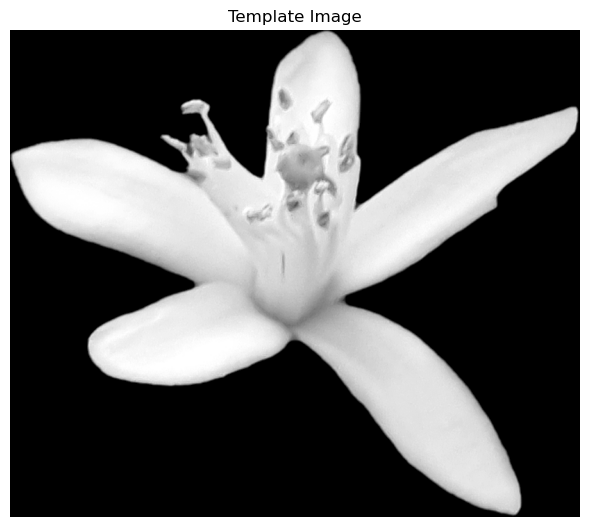

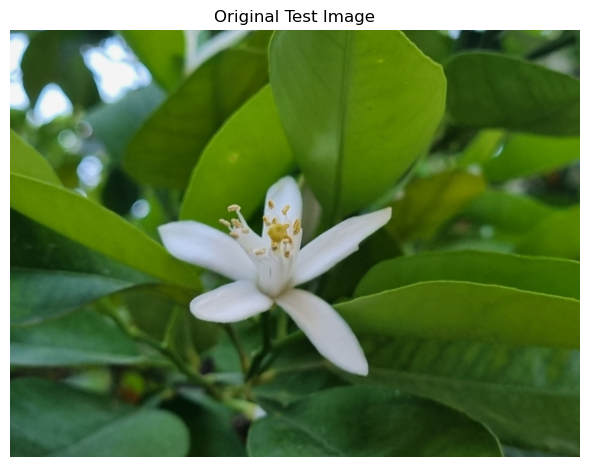

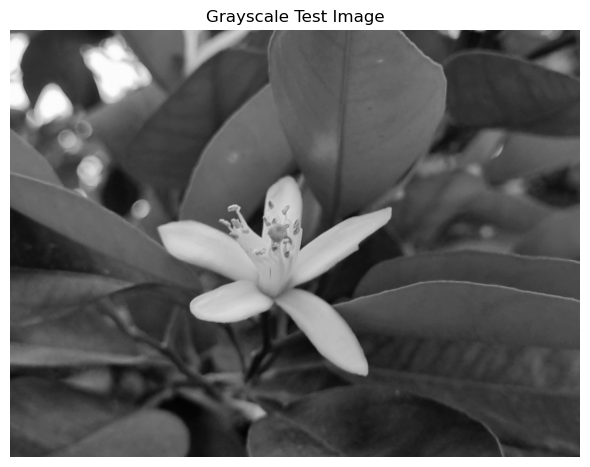

In [36]:
template_rgb = read_image(TEMPLATE_PATH)
test_rgb = read_image(TEST_PATH)

template_gray = rgb_to_gray(template_rgb)
test_gray = rgb_to_gray(test_rgb)

save_image(OUTPUT_DIR / "01_original_test.png", test_rgb)
save_image(OUTPUT_DIR / "02_grayscale_test.png", test_gray, cmap="gray")

show_image(template_rgb, "Template Image")
show_image(test_rgb, "Original Test Image")
show_image(test_gray, "Grayscale Test Image", cmap="gray")

## 6. Run edge detection on template and test image

You may need to tune `template_threshold_ratio` and `test_threshold_ratio` depending on the dataset contrast.

Edge detection time: 0.9510 seconds


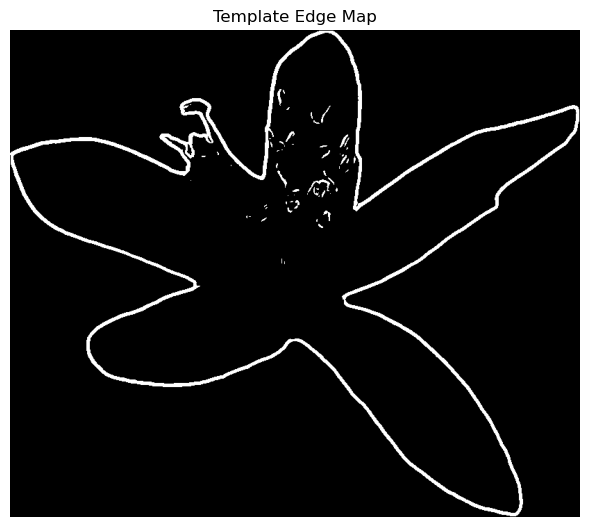

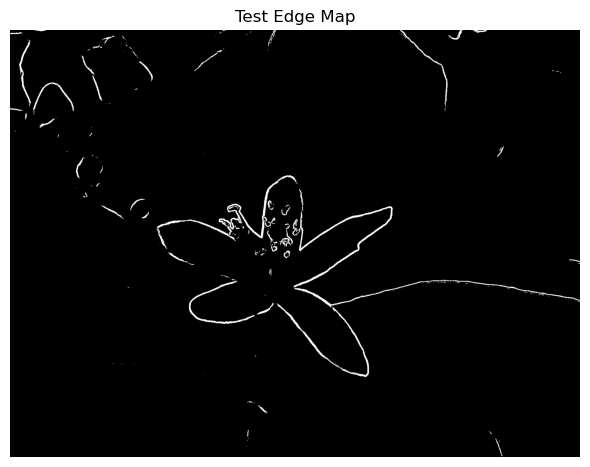

In [37]:
template_threshold_ratio = 0.22
test_threshold_ratio = 0.22

t0 = time.time()

template_edges, template_mag, template_phi = edge_detection_scratch(
    template_gray,
    gaussian_size=5,
    sigma=1.0,
    threshold_ratio=template_threshold_ratio
)

test_edges, test_mag, test_phi = edge_detection_scratch(
    test_gray,
    gaussian_size=5,
    sigma=1.0,
    threshold_ratio=test_threshold_ratio
)

edge_time = time.time() - t0
print(f"Edge detection time: {edge_time:.4f} seconds")

save_image(OUTPUT_DIR / "03_edge_map.png", test_edges, cmap="gray")

show_image(template_edges, "Template Edge Map", cmap="gray")
show_image(test_edges, "Test Edge Map", cmap="gray")

## 7. Build the R-table from the template

The reference point is selected as the centroid of the template edge pixels.

In [38]:
num_bins = 180

t0 = time.time()

reference_point = choose_reference_point(template_edges)
r_table = build_r_table(template_edges, template_phi, reference_point, num_bins=num_bins)

r_table_time = time.time() - t0

non_empty_bins = sum(1 for item in r_table if item.shape[0] > 0)
total_vectors = sum(item.shape[0] for item in r_table)

print("Reference point:", reference_point)
print("Non-empty R-table bins:", non_empty_bins)
print("Total stored vectors:", total_vectors)
print(f"R-table construction time: {r_table_time:.4f} seconds")

Reference point: (420, 299)
Non-empty R-table bins: 180
Total stored vectors: 20758
R-table construction time: 0.0930 seconds


## 8. Generalized Hough voting

The accumulator is a 2D image-sized voting space. The strongest peak is the estimated flower center.

Generalized Hough voting time: 1.8677 seconds


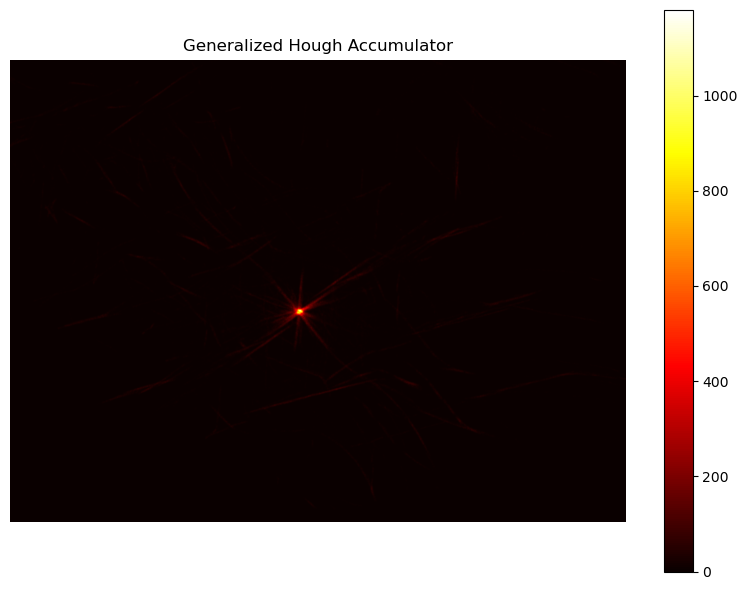

In [39]:
t0 = time.time()

accumulator = generalized_hough_vote(
    test_edges,
    test_phi,
    r_table,
    num_bins=num_bins,
    max_vectors_per_bin=300
)

voting_time = time.time() - t0
print(f"Generalized Hough voting time: {voting_time:.4f} seconds")

save_image(
    OUTPUT_DIR / "04_accumulator_heatmap.png",
    accumulator,
    cmap="hot",
    title="Generalized Hough Accumulator",
    colorbar=True
)

plt.figure(figsize=(8, 6))
plt.imshow(accumulator, cmap="hot")
plt.title("Generalized Hough Accumulator")
plt.axis("off")
plt.colorbar()
plt.tight_layout()
plt.show()

## 9. Detect strongest peak and draw final location

Detected center: (964, 833)
Peak value: 1180.00
Peak detection time: 0.0177 seconds


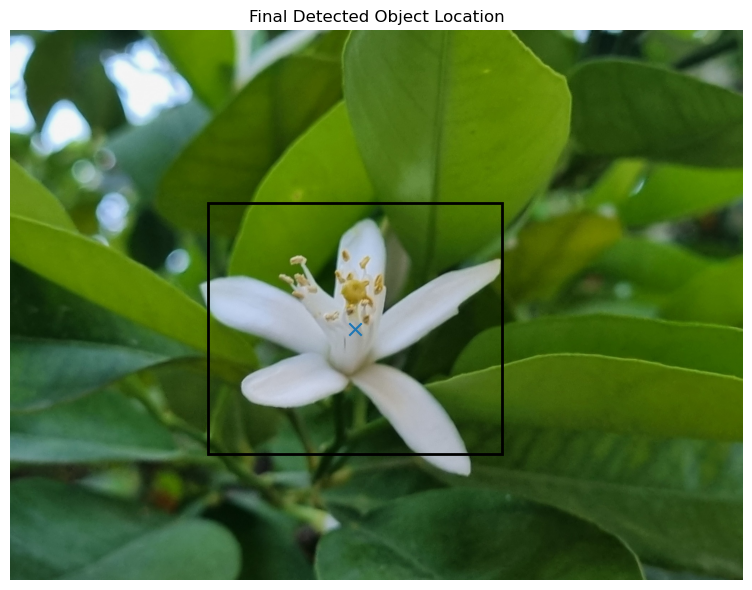

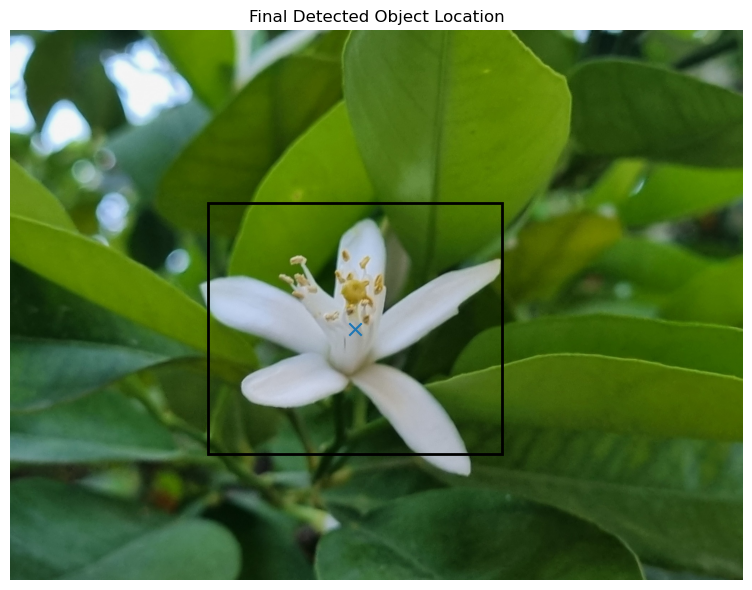

In [40]:
t0 = time.time()

center_x, center_y, peak_value = detect_peak(accumulator)
post_time = time.time() - t0

print(f"Detected center: ({center_x}, {center_y})")
print(f"Peak value: {peak_value:.2f}")
print(f"Peak detection time: {post_time:.4f} seconds")

draw_detection(test_rgb, center=(center_x, center_y), template_shape=template_rgb.shape)

# Save final detection
center = (center_x, center_y)
template_h, template_w = template_rgb.shape[:2]
x0 = center_x - template_w // 2
y0 = center_y - template_h // 2

plt.figure(figsize=(8, 6))
plt.imshow(test_rgb)
plt.scatter([center_x], [center_y], s=80, marker="x")
plt.gca().add_patch(plt.Rectangle((x0, y0), template_w, template_h, fill=False, linewidth=2))
plt.title("Final Detected Object Location")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_final_detection.png", bbox_inches="tight", pad_inches=0)
plt.show()

## 10. Timing summary

Use this table in the report's performance analysis section.

In [42]:
timings = {
    "Edge Detection": edge_time,
    "R-table Construction": r_table_time,
    "Generalized Hough Voting": voting_time,
    "Peak Detection": post_time,
}

print("Part 3 execution times")
print("-" * 40)
for stage, seconds in timings.items():
    print(f"{stage:30s}: {seconds:.4f} seconds")

print("Saved outputs:")
for path in sorted(OUTPUT_DIR.glob("*.png")):
    print("-", path)

Part 3 execution times
----------------------------------------
Edge Detection                : 0.9510 seconds
R-table Construction          : 0.0930 seconds
Generalized Hough Voting      : 1.8677 seconds
Peak Detection                : 0.0177 seconds
Saved outputs:
- outputs\object_localization\01_original_test.png
- outputs\object_localization\02_grayscale_test.png
- outputs\object_localization\03_edge_map.png
- outputs\object_localization\04_accumulator_heatmap.png
- outputs\object_localization\05_final_detection.png


## Notes for the report

For Part 3, describe the method as follows:

- The template and test images are converted to grayscale.
- A custom edge detector computes gradient magnitude and direction.
- The template reference point is selected as the centroid of edge pixels.
- The R-table maps quantized gradient directions to displacement vectors from edge pixels to the reference point.
- Each test edge pixel retrieves displacement vectors according to its gradient direction and votes for possible object centers in a 2D accumulator.
- The strongest accumulator peak is selected as the detected object location.

Required visuals saved by this notebook:

1. `01_original_test.png`
2. `02_grayscale_test.png`
3. `03_edge_map.png`
4. `04_accumulator_heatmap.png`
5. `05_final_detection.png`